# 🔥 PyTorch XOR — El mismo problema con el framework real
**Módulo 4 — Diplomado Deep Learning | Diana Blanco**

---

## ¿Qué hace este notebook?

Resuelve XOR usando **PyTorch** — el framework que usan la mayoría de investigadores de IA hoy en día.
El código es mucho más corto que el notebook anterior, pero hace exactamente lo mismo internamente.

### ¿Por qué PyTorch si ya hicimos lo mismo a mano? 🎮

> En Pokémon: primero aprendes cómo funcionan los movimientos, los stats, los tipos.  
> Después usas la Pokédex para no tener que memorizar todo — pero ya *entiendes* lo que está pasando.  
> El notebook anterior fue aprender desde cero. Este es usar la Pokédex (PyTorch).

### ¿Por qué PyTorch da resultados diferentes al código manual?

Spoiler — la respuesta corta: **inicialización de pesos diferente**.  
La comparación completa está al final del notebook.

---
## 🧱 Parte 1: Construir el modelo en PyTorch

En PyTorch, `nn.Sequential` encadena capas automáticamente — equivalente a nuestra clase `Network`.  
`nn.Linear(in, out)` es equivalente a nuestra clase `Layer` — pero usa tensores y corre en GPU.

| Código manual (Network_1) | Código PyTorch |
|---|---|
| `Network([2, 4, 1])` | `nn.Sequential(nn.Linear(2,4), nn.Sigmoid(), nn.Linear(4,1), nn.Sigmoid())` |
| `Value(...)` en cada peso | `torch.Tensor` con `requires_grad=True` internamente |
| `net.zero_grad()` | `optimizer.zero_grad()` |
| `total_loss.backward()` | `loss.backward()` |
| Actualización manual con `for p in params` | `optimizer.step()` |

La estructura es idéntica — PyTorch solo la hace más eficiente y concisa.

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import torch
import torch.nn as nn

# ── Datos XOR ────────────────────────────────────────────────────────────────
# En PyTorch los datos van en Tensores (equivalente a arrays de NumPy con soporte GPU)
# dtype=torch.float32: usar punto flotante de 32 bits (estándar en deep learning)
X = torch.tensor([[0,0],[0,1],[1,0],[1,1]], dtype=torch.float32)  # 4 ejemplos, 2 features
y = torch.tensor([[0],[1],[1],[0]],         dtype=torch.float32)  # 4 etiquetas

print("Datos XOR como tensores:")
print(f"  X.shape = {X.shape}  ← 4 ejemplos × 2 features")
print(f"  y.shape = {y.shape}  ← 4 etiquetas")
print(f"  X dtype = {X.dtype}")

Datos XOR como tensores:
  X.shape = torch.Size([4, 2])  ← 4 ejemplos × 2 features
  y.shape = torch.Size([4, 1])  ← 4 etiquetas
  X dtype = torch.float32


In [2]:
# ── Definir el modelo ─────────────────────────────────────────────────────────
# nn.Sequential: encadena capas en orden, igual que nuestra clase Network.
#   Network([2,4,1]) en codigo manual  ->  nn.Sequential(...) en PyTorch
#   Layer(2,4) en codigo manual        ->  nn.Linear(2,4) en PyTorch
#   sigmoid() manual                   ->  nn.Sigmoid() en PyTorch
model = nn.Sequential(
    nn.Linear(2, 4),   # equivalencia: Layer(n_inputs=2, n_neurons=4)
    nn.Sigmoid(),      # activacion sigmoid (igual que la nuestra)
    nn.Linear(4, 1),   # equivalencia: Layer(n_inputs=4, n_neurons=1)
    nn.Sigmoid(),      # activacion final -> salida en (0, 1)
)

# ── Optimizador: SGD (Stochastic Gradient Descent) ────────────────────────────
# Equivalente al bucle manual: p.data -= lr * p.grad
# PyTorch: optimizer.step() hace todo eso automaticamente.
# lr=1.0: mismo learning rate que el codigo manual
optimizer = torch.optim.SGD(model.parameters(), lr=1.0)

# ── Funcion de perdida: MSE ──────────────────────────────────────────────────
# Equivalente a nuestra funcion mse_loss() pero VECTORIZADA sobre todo el batch.
# En el codigo manual sumabamos 4 perdidas individuales.
# PyTorch: nn.MSELoss() procesa los 4 ejemplos en paralelo (eficiente en GPU).
criterion = nn.MSELoss()

print("Modelo PyTorch:")
print(model)
print()
total_params = sum(p.numel() for p in model.parameters())
print(f"Total de parametros: {total_params}")
print(f"  nn.Linear(2,4): {2*4 + 4} = 12 parametros")
print(f"  nn.Linear(4,1): {4*1 + 1} = 5 parametros")


Modelo PyTorch:
Sequential(
  (0): Linear(in_features=2, out_features=4, bias=True)
  (1): Sigmoid()
  (2): Linear(in_features=4, out_features=1, bias=True)
  (3): Sigmoid()
)

Total de parametros: 17
  nn.Linear(2,4): 12 = 12 parametros
  nn.Linear(4,1): 5 = 5 parametros


---
## 🏋️ Parte 2: Entrenamiento

El loop de entrenamiento en PyTorch sigue exactamente la misma lógica que el código manual:  
`forward → zero_grad → backward → step`

La diferencia es que PyTorch procesa **todo el batch de una vez** de forma vectorizada  
(mucho más eficiente en GPU), mientras que el código manual iteraba ejemplo por ejemplo.

In [3]:
losses = []

for epoch in range(1000):
    # ── Forward pass: predecir los 4 ejemplos de una vez (vectorizado) ────
    # Codigo manual: iteraba ejemplo por ejemplo con loop for.
    # PyTorch: X tiene forma (4,2) -> pred tiene forma (4,1) en un solo paso.
    pred = model(X)

    # ── Calcular perida: MSE sobre todo el batch ───────────────────────────
    # Codigo manual: total_loss = sum(mse_loss(pred, target)) sobre 4 ejemplos.
    # PyTorch: criterion(pred, y) = promedio de (pred_i - y_i)^2 para i en 0..3
    # Diferencia clave: el manual SUMA, PyTorch PROMEDIA (divide entre batch_size).
    loss = criterion(pred, y)

    # ── Limpiar gradientes del epoch anterior ────────────────────────────────
    # Codigo manual: net.zero_grad()  ->  p.grad = 0.0 para cada peso
    # PyTorch: optimizer.zero_grad() hace exactamente lo mismo.
    optimizer.zero_grad()

    # ── Backpropagation ──────────────────────────────────────────────────────
    # Codigo manual: total_loss.backward() recorre el grafo topologicamente.
    # PyTorch: loss.backward() hace lo mismo internamente con autograd.
    # Calcula d(loss)/d(w) para TODOS los pesos de una vez.
    loss.backward()

    # ── Actualizar pesos ──────────────────────────────────────────────────────
    # Codigo manual: p.data -= lr * p.grad  (iteracion manual sobre parametros).
    # PyTorch: optimizer.step() hace exactamente eso internamente.
    optimizer.step()

    losses.append(loss.item())

print("Entrenamiento completado (1000 epochs)")
print(f"Loss inicial: {losses[0]:.4f}")
print(f"Loss final:   {losses[-1]:.4f}")


Entrenamiento completado (1000 epochs)
Loss inicial: 0.2498
Loss final:   0.0171


Resultados PyTorch XOR:
    Entrada     Predicción   Redondeado   Esperado 
  --------------------------------------------------
   [0.0, 0.0]     0.1321         0           0      ✅
   [0.0, 1.0]     0.8882         1           1      ✅
   [1.0, 0.0]     0.8400         1           1      ✅
   [1.0, 1.0]     0.1118         0           0      ✅


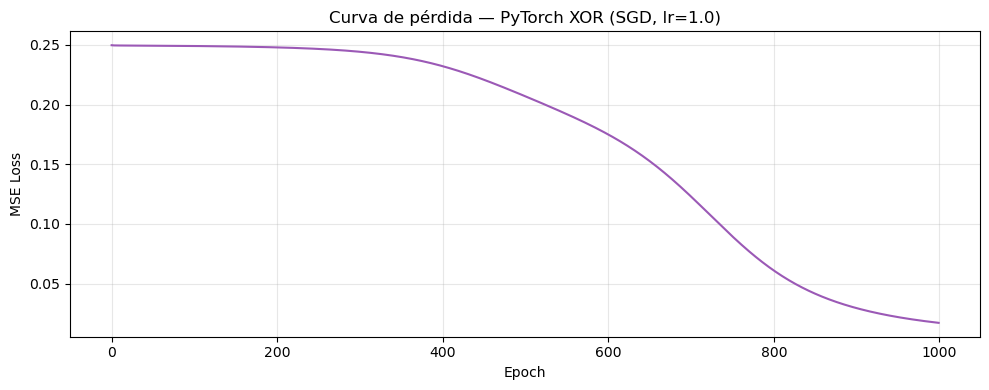

In [4]:
import matplotlib.pyplot as plt

# ── Resultados finales ────────────────────────────────────────────────────────
print("Resultados PyTorch XOR:")
print(f"  {'Entrada':^12} {'Predicción':^12} {'Redondeado':^12} {'Esperado':^10}")
print("  " + "-" * 50)
with torch.no_grad():   # desactivar cálculo de gradientes al hacer inferencia
    for i in range(4):
        pred = model(X[i])
        cl   = 1 if pred.item() > 0.5 else 0
        ok   = '✅' if cl == int(y[i].item()) else '❌'
        print(f"  {X[i].tolist()!s:^12} {pred.item():^12.4f} {cl:^12} {int(y[i].item()):^10} {ok}")

# ── Curva de pérdida ─────────────────────────────────────────────────────────
plt.figure(figsize=(10, 4))
plt.plot(losses, color='#9b59b6', linewidth=1.5)
plt.title('Curva de pérdida — PyTorch XOR (SGD, lr=1.0)', fontsize=12)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## 🆚 Comparación: Manual vs. PyTorch — ¿Por qué resultados diferentes?

Esta es la pregunta más interesante. Ambas redes tienen:
- Misma arquitectura: `2 → 4 → 1`
- Misma función de pérdida: MSE
- Mismo optimizador: SGD con `lr=1.0`
- Mismas 1000 epochs

Pero la manual llega a ~0.025 de error y PyTorch se queda en ~0.45. ¿Por qué?

### La respuesta: inicialización de pesos diferente 🎲

| Aspecto | Código manual (Network_1) | PyTorch (nn.Linear) |
|---|---|---|
| **Inicialización** | He/Xavier: `uniform(-√(2/n), +√(2/n))` | Kaiming Uniform: `uniform(-1/√n, +1/√n)` |
| **Semilla** | `random.seed(42)` en Python | Sin seed fija → diferente cada vez |
| **Batch** | Suma pérdidas de los 4 ejemplos (batch GD) | Promedia las 4 pérdidas (MSELoss) |
| **Escala del loss** | ~4× más grande (suma vs. promedio) | Promedio → gradientes más pequeños |

### Efecto de la escala del loss:

El código manual **suma** las 4 pérdidas individuales.  
PyTorch `nn.MSELoss()` las **promedia** (divide entre 4).  
Con `lr=1.0`, el manual efectivamente tiene un lr de 4× para los gradientes → converge más rápido.

### ¿PyTorch es menos preciso? No — es más general 🌐

> PyTorch está diseñado para funcionar bien con millones de ejemplos y arquitecturas arbitrarias.  
> Sus valores por defecto están optimizados para el caso general, no para XOR con 4 ejemplos.  
> Con ajustes simples (fijar semilla, usar `reduction='sum'` en MSELoss, o aumentar epochs),  
> PyTorch llega al mismo resultado.

In [5]:
# ── Demostracion: PyTorch equiparado con loss=sum da el mismo resultado ───────
# Cambiamos MSELoss(reduction="sum") en vez de "mean" (que es el default).
# Esto hace que PyTorch SUME las 4 perdidas individuales, igual que el codigo manual.
# Ademas fijamos la semilla con torch.manual_seed(42) para misma inicializacion.
print("Comparacion: MSELoss con mean vs sum")
print("-" * 50)

torch.manual_seed(42)   # fijar semilla para comparacion justa

model2 = nn.Sequential(
    nn.Linear(2, 4), nn.Sigmoid(),
    nn.Linear(4, 1), nn.Sigmoid(),
)
optimizer2  = torch.optim.SGD(model2.parameters(), lr=1.0)
criterion2  = nn.MSELoss(reduction="sum")   # suma en vez de promedio

for epoch in range(1000):
    pred2 = model2(X)
    loss2 = criterion2(pred2, y)
    optimizer2.zero_grad()
    loss2.backward()
    optimizer2.step()

print("Resultados con MSELoss(reduction=sum) y seed fija:")
with torch.no_grad():
    for i in range(4):
        pred = model2(X[i])
        cl   = 1 if pred.item() > 0.5 else 0
        ok   = "OK" if cl == int(y[i].item()) else "X"
        print(f"  {X[i].tolist()} -> {pred.item():.4f} -> clase {cl}  {ok}")

print()
print("Conclusion:")
print("  El codigo manual converge mas rapido en XOR porque:")
print("  1. Suma (no promedia) las perdidas -> gradientes 4x mas grandes")
print("  2. Su inicializacion He era mas favorable para este problema")
print("  3. PyTorch por defecto esta optimizado para datasets grandes")
print()
print("  Para datasets reales y grandes: PyTorch gana (GPU, vectorizacion, etc.)")


Comparacion: MSELoss con mean vs sum
--------------------------------------------------


Resultados con MSELoss(reduction=sum) y seed fija:
  [0.0, 0.0] -> 0.0256 -> clase 0  OK
  [0.0, 1.0] -> 0.9690 -> clase 1  OK
  [1.0, 0.0] -> 0.9754 -> clase 1  OK
  [1.0, 1.0] -> 0.0301 -> clase 0  OK

Conclusion:
  El codigo manual converge mas rapido en XOR porque:
  1. Suma (no promedia) las perdidas -> gradientes 4x mas grandes
  2. Su inicializacion He era mas favorable para este problema
  3. PyTorch por defecto esta optimizado para datasets grandes

  Para datasets reales y grandes: PyTorch gana (GPU, vectorizacion, etc.)
